In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
# Display Image
from PIL import Image
import cv2
import os

In [2]:
os.listdir("skin_infections_datasets")

['Vi Chickenpox',
 'Vi Shingles',
 'Ba Impetigo',
 'Fu Ringworm',
 'Ba  Cellulitis',
 'Fu Athlete Foot',
 'Fu Nail Fungus']

# Data Visualization

In [3]:
# Data Classes
classes = os.listdir("skin_infections_datasets")
classes = sorted(classes)
print(f"Total classes = {len(classes)}")
print(f"Classes: {classes}")

Total classes = 7
Classes: ['Ba  Cellulitis', 'Ba Impetigo', 'Fu Athlete Foot', 'Fu Nail Fungus', 'Fu Ringworm', 'Vi Chickenpox', 'Vi Shingles']


In [4]:
# Count images in data set
dir = "skin_infections_datasets"
total_images = 0
for category in os.listdir(dir):
  category_dir = os.path.join(dir, category)
  num_images = len(os.listdir(category_dir))
  print(f"{category}: {num_images} images")
  total_images += num_images
print(f"\nTotal images: {total_images}")

Vi Chickenpox: 8083 images
Vi Shingles: 8082 images
Ba Impetigo: 8148 images
Fu Ringworm: 8129 images
Ba  Cellulitis: 8079 images
Fu Athlete Foot: 8054 images
Fu Nail Fungus: 8083 images

Total images: 56658


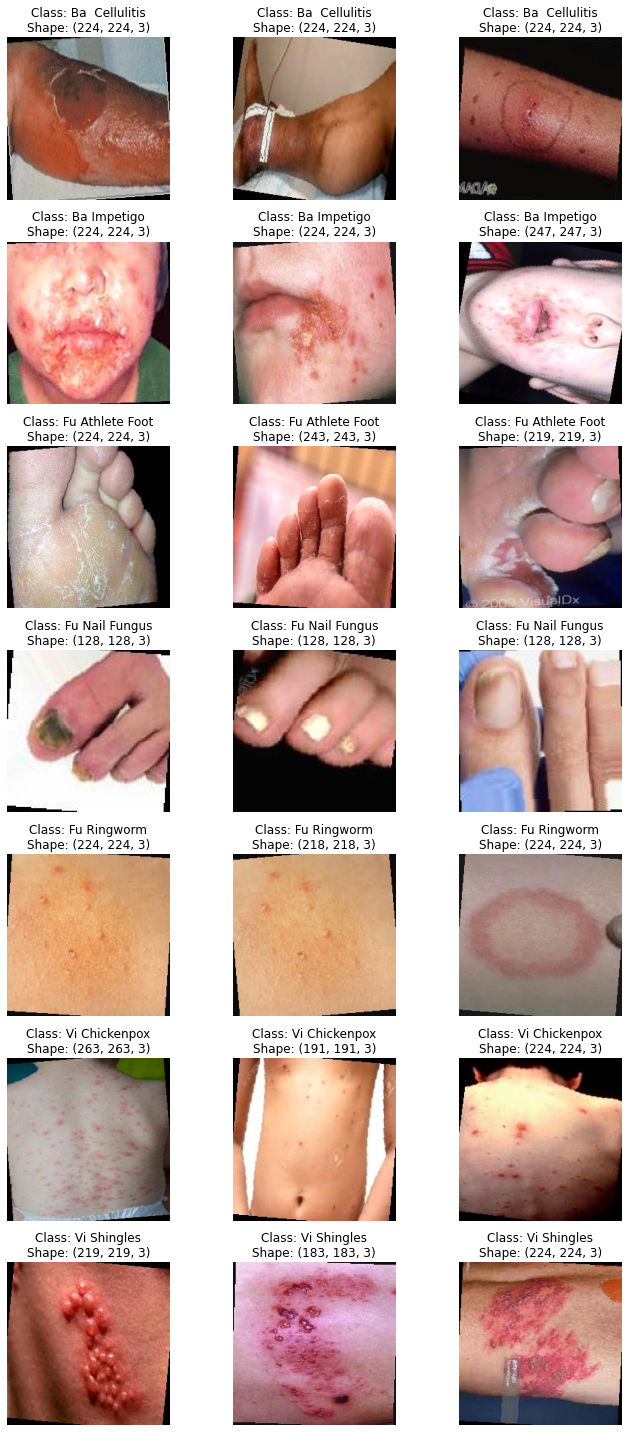

In [5]:
# visualize some images from our data set.
from pathlib import Path
import random
NUM_IMAGES = 3

fig, ax = plt.subplots(nrows = len(classes), ncols = NUM_IMAGES, figsize = (10, 20))

p = 0

for c in classes:
    img_path_class = list(Path(os.path.join(dir,c)).glob("*.jpg"))
    img_selected = random.choices(img_path_class, k = NUM_IMAGES)
    for i,j in enumerate(img_selected):
        img_bgr = cv2.imread(str(j))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax[p,i].imshow(img_rgb)
        ax[p,i].set_title(f"Class: {c}\nShape: {img_rgb.shape}")
        ax[p,i].axis('off')

    p += 1

fig.tight_layout()
fig.show()

In [6]:
Ba_Impetigo = os.listdir('skin_infections_datasets/Ba Impetigo')
Ba_Cellulitis = os.listdir('skin_infections_datasets/Ba  Cellulitis')
Fu_AthleteFoot = os.listdir('skin_infections_datasets/Fu Athlete Foot')
Fu_NailFungus = os.listdir('skin_infections_datasets/Fu Nail Fungus')
Fu_Ringworm = os.listdir('skin_infections_datasets/Fu Ringworm')
Vi_Chickenpox = os.listdir('skin_infections_datasets/Vi Chickenpox')
Vi_Shingles = os.listdir('skin_infections_datasets/Vi Shingles')


In [7]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

# Base dataset folder — contains subfolders for each class
base_dataset_dir = "skin_infections_datasets"

# List all class names
class_folders = sorted(os.listdir(base_dataset_dir))

# Collect file paths & labels
file_paths = []
labels = []

for idx, class_name in enumerate(class_folders):
    class_dir = os.path.join(base_dataset_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    for file_name in os.listdir(class_dir):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            file_paths.append(os.path.join(class_dir, file_name))
            labels.append(idx)

file_paths = np.array(file_paths)
labels = np.array(labels)

print(f"Total images found: {len(file_paths)}")
print(f"Classes: {class_folders}")



Total images found: 56658
Classes: ['Ba  Cellulitis', 'Ba Impetigo', 'Fu Athlete Foot', 'Fu Nail Fungus', 'Fu Ringworm', 'Vi Chickenpox', 'Vi Shingles']


In [8]:
# 70% train, 15% val, 15% test
x_train, x_temp, y_train, y_temp = train_test_split(file_paths, labels,test_size=0.3, stratify=labels, random_state=42)

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp,test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")


Train: 39660, Val: 8499, Test: 8499


In [9]:
def create_split_folders(X, y, base_dir, class_names):
    for img_path, label in zip(X, y):
        label_name = class_names[label]
        label_dir = os.path.join(base_dir, label_name)
        os.makedirs(label_dir, exist_ok=True)
        shutil.copy(img_path, os.path.join(label_dir, os.path.basename(img_path)))



In [10]:
output_base = "split_dataset"

# Create split folders
create_split_folders(x_train, y_train, os.path.join(output_base, "train"), class_folders)
create_split_folders(x_val,   y_val,   os.path.join(output_base, "val"),   class_folders)
create_split_folders(x_test,  y_test,  os.path.join(output_base, "test"),  class_folders)

print("✅ Dataset successfully split into train/val/test folders.")



✅ Dataset successfully split into train/val/test folders.


In [11]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
print(x_val.shape)
print(y_val.shape)

(39660,)
(39660,)
(8499,)
(8499,)
(8499,)
(8499,)


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set parameters
img_size = (224, 224)
batch_size = 128

# Paths to your split dataset
train_dir = "split_dataset/train"
val_dir   = "split_dataset/val"
test_dir  = "split_dataset/test"

# No augmentation — just rescaling
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',  # integer labels
    shuffle=False
)

val_gen = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)


2025-08-21 04:31:04.013009: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 39660 images belonging to 7 classes.
Found 8499 images belonging to 7 classes.
Found 8500 images belonging to 7 classes.
Class indices: {'Ba  Cellulitis': 0, 'Ba Impetigo': 1, 'Fu Athlete Foot': 2, 'Fu Nail Fungus': 3, 'Fu Ringworm': 4, 'Vi Chickenpox': 5, 'Vi Shingles': 6}


In [13]:
def map_to_stage1_labels(y):
    mapping = {
        0: 0,  # bacterial
        1: 0,  # bacterial
        2: 1,  # fungal
        3: 1,  # fungal
        4: 1,  # fungal
        5: 2,  # viral
        6: 2   # viral
    }
    return np.array([mapping[int(label)] for label in y])

train_labels_stage1 = map_to_stage1_labels(train_gen.classes)
val_labels_stage1   = map_to_stage1_labels(val_gen.classes)
test_labels_stage1  = map_to_stage1_labels(test_gen.classes)


In [14]:
train_gen.class_indices

{'Ba  Cellulitis': 0,
 'Ba Impetigo': 1,
 'Fu Athlete Foot': 2,
 'Fu Nail Fungus': 3,
 'Fu Ringworm': 4,
 'Vi Chickenpox': 5,
 'Vi Shingles': 6}

In [15]:
train_gen_stage1 = datagen.flow_from_directory("split_dataset/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)
train_gen_stage1.classes = train_labels_stage1  # override labels

val_gen_stage1 = datagen.flow_from_directory(
    "split_dataset/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)
val_gen_stage1.classes = val_labels_stage1

test_gen_stage1 = datagen.flow_from_directory(
    "split_dataset/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)
test_gen_stage1.classes = test_labels_stage1

Found 39660 images belonging to 7 classes.
Found 8499 images belonging to 7 classes.
Found 8500 images belonging to 7 classes.


# Stage1 Baseline CNN

In [16]:
# Baseline CNN MODEL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout

In [17]:
from tensorflow.keras import layers, models

num_classes = 3  # bacterial, fungal, viral

model = models.Sequential([
    layers.Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = 'same',input_shape = (224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),
    
    layers.Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),
    
    layers.Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 112, 112, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 56, 56, 64)        0

2025-08-21 04:34:17.185342: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1952] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2025-08-21 04:34:17.192212: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-21 04:34:17.228347: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1952] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2025-08-21 04:42:52.684852: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/t

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("stage1_baseline_best.h5", save_best_only=True, monitor="val_loss"),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]


In [19]:
EPOCHS = 20
history = model.fit(train_gen_stage1,
    validation_data=val_gen_stage1,epochs=EPOCHS,callbacks=callbacks)


Epoch 1/20


2025-08-21 04:53:27.406132: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8401
2025-08-21 05:02:34.762785: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 9.0
2025-08-21 05:02:34.762821: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2025-08-21 05:02:34.762882: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-08-21 05:02:35.076085: I tensorflow/stream_executor/cuda/cuda_blas.cc:1804] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


310/310 [==============================] - 1435s 266ms/step - loss: 1.1461 - accuracy: 0.5375 - val_loss: 0.5722 - val_accuracy: 0.7789 - lr: 0.0010
Epoch 2/20
310/310 [==============================] - 84s 271ms/step - loss: 0.3295 - accuracy: 0.8709 - val_loss: 0.1493 - val_accuracy: 0.9554 - lr: 0.0010
Epoch 3/20
310/310 [==============================] - 88s 284ms/step - loss: 0.1042 - accuracy: 0.9651 - val_loss: 0.0389 - val_accuracy: 0.9887 - lr: 0.0010
Epoch 4/20
310/310 [==============================] - 87s 280ms/step - loss: 0.0437 - accuracy: 0.9853 - val_loss: 0.0194 - val_accuracy: 0.9948 - lr: 0.0010
Epoch 5/20
310/310 [==============================] - 87s 280ms/step - loss: 0.0290 - accuracy: 0.9909 - val_loss: 0.0172 - val_accuracy: 0.9958 - lr: 0.0010
Epoch 6/20
310/310 [==============================] - 85s 274ms/step - loss: 0.0206 - accuracy: 0.9934 - val_loss: 0.0102 - val_accuracy: 0.9972 - lr: 0.0010
Epoch 7/20
310/310 [==============================] - 87s 282

In [20]:
loss,test_accuracy = model.evaluate(test_gen_stage1)

67/67 [==============================] - 15s 220ms/step - loss: 0.0011 - accuracy: 0.9995


In [21]:
test_accuracy,loss

(0.9995294213294983, 0.0010866920929402113)

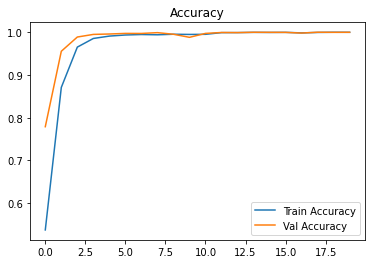

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot()
plt.title('Accuracy')
plt.legend()
plt.show()

In [23]:
print(test_labels_stage1)

[0 0 0 ... 2 2 2]


In [24]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
# Predictions
y_pred_probs = model.predict(test_gen_stage1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_labels_stage1  # should already be 0,1,2


# Classification report
print(classification_report(y_true,y_pred,target_names=["Bacterial", "Fungal", "Viral"]))

67/67 [==============================] - 13s 186ms/step
              precision    recall  f1-score   support

   Bacterial       1.00      1.00      1.00      2435
      Fungal       1.00      1.00      1.00      3640
       Viral       1.00      1.00      1.00      2425

    accuracy                           1.00      8500
   macro avg       1.00      1.00      1.00      8500
weighted avg       1.00      1.00      1.00      8500



In [25]:
!pip install seaborn

--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1752, in print
    extend(render(renderable, render_options))
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1390, in render
    for render_output in iter_render:
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/segment.py", line 245, in split_lines
    for segment in segments:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1368, in render
    renderable = rich_cast(renderable)
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/protocol.py", line 36

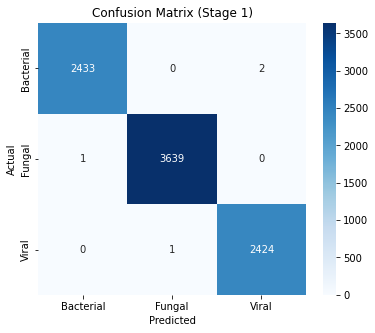

In [26]:
import seaborn as sns
# 4️⃣ Confusion matrix
class_names = ["Bacterial", "Fungal", "Viral"]
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Stage 1)')
plt.show()

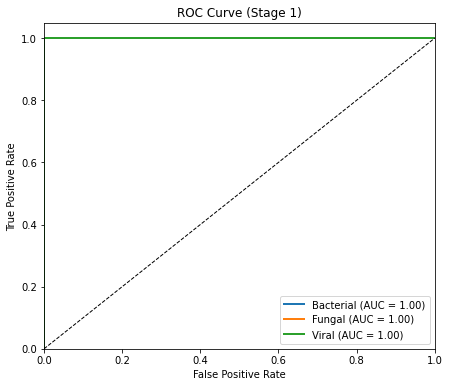

In [27]:
# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

plt.figure(figsize=(7, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)  # Diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Stage 1)')
plt.legend(loc="lower right")
plt.show()

# EfficientNetB0 Model

In [28]:
# STEP 1: Install dependencies (if needed)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (EfficientNetB0,ResNet50,MobileNetV2)
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os


In [29]:
def build_model(base_model_fn, input_shape=(224, 224, 3), num_classes=3):
    base_model = base_model_fn(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Freeze base

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model


In [30]:
eff_model = build_model(EfficientNetB0, input_shape=(224,224,3), num_classes=3)
eff_model.fit(train_gen_stage1,validation_data=val_gen_stage1, epochs=20)
eff_model.save("stage1_efficientnetb0.h5")


Epoch 1/20
310/310 [==============================] - 89s 275ms/step - loss: 1.0919 - accuracy: 0.4095 - val_loss: 1.0850 - val_accuracy: 0.4283
Epoch 2/20
310/310 [==============================] - 82s 266ms/step - loss: 1.0893 - accuracy: 0.4141 - val_loss: 1.0838 - val_accuracy: 0.4283
Epoch 3/20
310/310 [==============================] - 83s 267ms/step - loss: 1.0885 - accuracy: 0.4165 - val_loss: 1.0788 - val_accuracy: 0.4283
Epoch 4/20
310/310 [==============================] - 83s 269ms/step - loss: 1.0859 - accuracy: 0.4219 - val_loss: 1.0807 - val_accuracy: 0.4283
Epoch 5/20
310/310 [==============================] - 82s 263ms/step - loss: 1.0851 - accuracy: 0.4242 - val_loss: 1.0808 - val_accuracy: 0.4283
Epoch 6/20
310/310 [==============================] - 83s 266ms/step - loss: 1.0853 - accuracy: 0.4210 - val_loss: 1.0795 - val_accuracy: 0.4283
Epoch 7/20
310/310 [==============================] - 84s 270ms/step - loss: 1.0839 - accuracy: 0.4240 - val_loss: 1.0796 - val_ac

In [31]:
loss,test_accuracy = eff_model.evaluate(test_gen_stage1)

67/67 [==============================] - 13s 198ms/step - loss: 1.0776 - accuracy: 0.4282


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
# Predictions
y_pred_probs = eff_model.predict(test_gen_stage1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_labels_stage1  # should already be 0,1,2


# Classification report
print(classification_report(y_true,y_pred,target_names=["Bacterial", "Fungal", "Viral"]))

67/67 [==============================] - 14s 189ms/step
              precision    recall  f1-score   support

   Bacterial       0.00      0.00      0.00      2435
      Fungal       0.43      1.00      0.60      3640
       Viral       0.00      0.00      0.00      2425

    accuracy                           0.43      8500
   macro avg       0.14      0.33      0.20      8500
weighted avg       0.18      0.43      0.26      8500



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


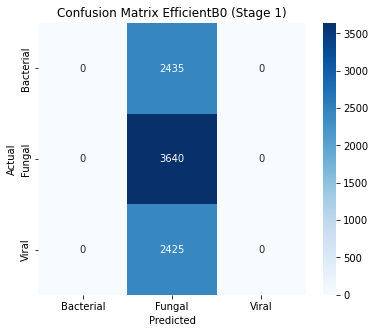

In [33]:
import seaborn as sns
# 4️⃣ Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix EfficientB0 (Stage 1)')
plt.show()

# RESNET50 Model

In [34]:
resnet_model = build_model(ResNet50, input_shape=(224,224,3), num_classes=3)
resnet_model.fit(train_gen_stage1,validation_data=val_gen_stage1, epochs=20)
resnet_model.save("stage1_resnet50.h5")


Epoch 1/20
310/310 [==============================] - 87s 272ms/step - loss: 1.0814 - accuracy: 0.4131 - val_loss: 1.0398 - val_accuracy: 0.4281
Epoch 2/20
310/310 [==============================] - 82s 262ms/step - loss: 1.0308 - accuracy: 0.4419 - val_loss: 1.0147 - val_accuracy: 0.4553
Epoch 3/20
310/310 [==============================] - 83s 268ms/step - loss: 1.0156 - accuracy: 0.4517 - val_loss: 0.9998 - val_accuracy: 0.4419
Epoch 4/20
310/310 [==============================] - 84s 272ms/step - loss: 1.0062 - accuracy: 0.4602 - val_loss: 1.0000 - val_accuracy: 0.4655
Epoch 5/20
310/310 [==============================] - 85s 272ms/step - loss: 0.9977 - accuracy: 0.4658 - val_loss: 0.9814 - val_accuracy: 0.4601
Epoch 6/20
310/310 [==============================] - 87s 276ms/step - loss: 0.9913 - accuracy: 0.4679 - val_loss: 0.9756 - val_accuracy: 0.4803
Epoch 7/20
310/310 [==============================] - 85s 274ms/step - loss: 0.9852 - accuracy: 0.4720 - val_loss: 0.9717 - val_ac

In [35]:
loss,test_accuracy = resnet_model.evaluate(test_gen_stage1)

67/67 [==============================] - 16s 230ms/step - loss: 0.9252 - accuracy: 0.5104


In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
# Predictions
y_pred_probs = resnet_model.predict(test_gen_stage1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_labels_stage1  # should already be 0,1,2


# Classification report
print(classification_report(y_true,y_pred,target_names=["Bacterial", "Fungal", "Viral"]))

67/67 [==============================] - 16s 222ms/step
              precision    recall  f1-score   support

   Bacterial       0.72      0.13      0.22      2435
      Fungal       0.48      0.88      0.62      3640
       Viral       0.61      0.34      0.43      2425

    accuracy                           0.51      8500
   macro avg       0.60      0.45      0.42      8500
weighted avg       0.58      0.51      0.45      8500



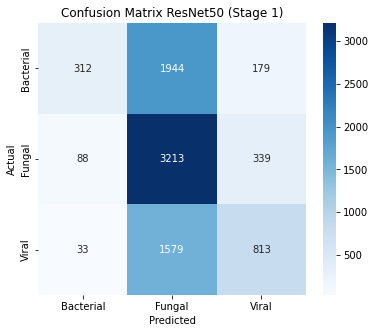

In [37]:
import seaborn as sns
# 4️⃣ Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix ResNet50 (Stage 1)')
plt.show()

# MobileNetV2 Model

In [38]:
mobilenet_model = build_model(MobileNetV2, input_shape=(224,224,3), num_classes=3)
mobilenet_model.fit(train_gen_stage1,validation_data=val_gen_stage1, epochs=20)
mobilenet_model.save("stage1_mobilenetv2.h5")


Epoch 1/20
310/310 [==============================] - 91s 284ms/step - loss: 0.3075 - accuracy: 0.8785 - val_loss: 0.1103 - val_accuracy: 0.9711
Epoch 2/20
310/310 [==============================] - 85s 276ms/step - loss: 0.1162 - accuracy: 0.9630 - val_loss: 0.0667 - val_accuracy: 0.9853
Epoch 3/20
310/310 [==============================] - 86s 278ms/step - loss: 0.0871 - accuracy: 0.9725 - val_loss: 0.0470 - val_accuracy: 0.9898
Epoch 4/20
310/310 [==============================] - 85s 274ms/step - loss: 0.0731 - accuracy: 0.9762 - val_loss: 0.0385 - val_accuracy: 0.9915
Epoch 5/20
310/310 [==============================] - 86s 277ms/step - loss: 0.0647 - accuracy: 0.9799 - val_loss: 0.0305 - val_accuracy: 0.9935
Epoch 6/20
310/310 [==============================] - 85s 273ms/step - loss: 0.0599 - accuracy: 0.9796 - val_loss: 0.0303 - val_accuracy: 0.9935
Epoch 7/20
310/310 [==============================] - 87s 280ms/step - loss: 0.0563 - accuracy: 0.9811 - val_loss: 0.0236 - val_ac

In [39]:
loss,test_accuracy = mobilenet_model.evaluate(test_gen_stage1)

67/67 [==============================] - 16s 233ms/step - loss: 0.0114 - accuracy: 0.9976


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
# Predictions
y_pred_probs = mobilenet_model.predict(test_gen_stage1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_labels_stage1  # should already be 0,1,2


# Classification report
print(classification_report(y_true,y_pred,target_names=["Bacterial", "Fungal", "Viral"]))

67/67 [==============================] - 16s 209ms/step
              precision    recall  f1-score   support

   Bacterial       1.00      1.00      1.00      2435
      Fungal       1.00      1.00      1.00      3640
       Viral       1.00      1.00      1.00      2425

    accuracy                           1.00      8500
   macro avg       1.00      1.00      1.00      8500
weighted avg       1.00      1.00      1.00      8500



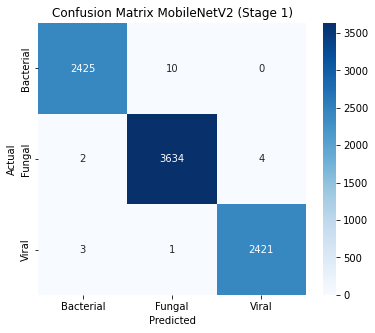

In [41]:
import seaborn as sns
# 4️⃣ Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix MobileNetV2 (Stage 1)')
plt.show()

# Confidence-Weighted Ensemble Model (stage-1)

In [42]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


In [43]:
# Load your trained models
mobilenet_model = load_model('stage1_mobilenetv2.h5')
baseline_cnn_model = load_model('stage1_baseline_best.h5')  
# Define Weights
w_baseline = 0.4
w_mobilenet = 0.6

In [44]:
#We use predict() to get class probabilities (confidence scores).
import numpy as np

baseline_preds = baseline_cnn_model.predict(test_gen_stage1, verbose=1)
mobilenet_preds = mobilenet_model.predict(test_gen_stage1, verbose=1)

67/67 [==============================] - 13s 188ms/step


In [45]:
ensemble_preds = (w_baseline * baseline_preds) + (w_mobilenet * mobilenet_preds)
ensemble_labels = np.argmax(ensemble_preds, axis=1)

In [46]:
true_labels = test_gen_stage1.classes
class_names = ["Bacterial", "Fungal", "Viral"]

In [47]:
# Classification report
print(classification_report(true_labels, ensemble_labels, target_names=class_names))

              precision    recall  f1-score   support

   Bacterial       1.00      1.00      1.00      2435
      Fungal       1.00      1.00      1.00      3640
       Viral       1.00      1.00      1.00      2425

    accuracy                           1.00      8500
   macro avg       1.00      1.00      1.00      8500
weighted avg       1.00      1.00      1.00      8500



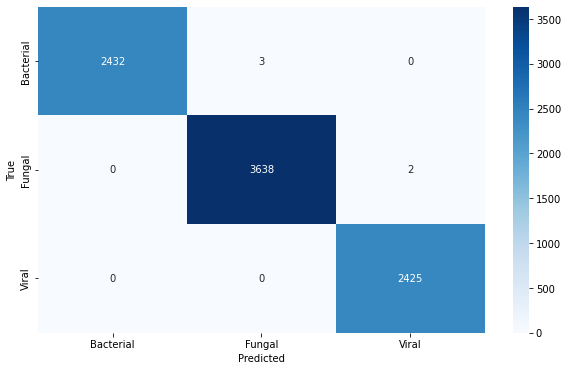

In [48]:
# Confusion matrix
cm = confusion_matrix(true_labels, ensemble_labels)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

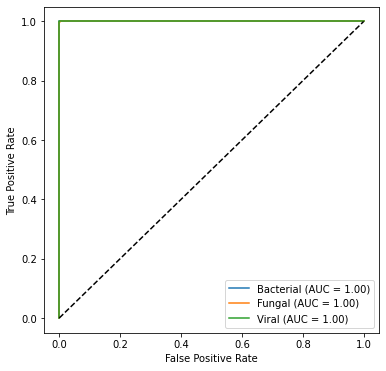

In [49]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels for ROC
y_true_bin = label_binarize(true_labels, classes=[0,1,2])

plt.figure(figsize=(6,6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], ensemble_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# Stage 2 ---classifications into subtypes

In [50]:
import os
import shutil

def prepare_stage2_data(original_base, stage2_base, target_classes):
    os.makedirs(stage2_base, exist_ok=True)
    for split in ['train', 'val', 'test']:
        split_src = os.path.join(original_base, split)
        split_dst = os.path.join(stage2_base, split)
        os.makedirs(split_dst, exist_ok=True)

        for cls in target_classes:
            src_dir = os.path.join(split_src, cls)
            dst_dir = os.path.join(split_dst, cls)
            os.makedirs(dst_dir, exist_ok=True)

            for file in os.listdir(src_dir):
                src_file = os.path.join(src_dir, file)
                if os.path.isfile(src_file):  # ✅ skip directories like .ipynb_checkpoints
                    shutil.copy(src_file, dst_dir)


In [51]:
prepare_stage2_data(
    original_base="split_dataset",
    stage2_base="stage2_bacterial_dataset",
    target_classes=["Ba Impetigo", "Ba  Cellulitis"]
)

In [52]:
prepare_stage2_data(
    original_base="split_dataset",
    stage2_base="stage2_fungal_dataset",
    target_classes=["Fu Athlete Foot", "Fu Nail Fungus","Fu Ringworm"]
)

In [53]:
prepare_stage2_data(
    original_base="split_dataset",
    stage2_base="stage2_viral_dataset",
    target_classes=["Vi Chickenpox", "Vi Shingles"]
)

In [54]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

def load_stage2_generators(stage2_dataset_path, img_size=(224, 224), batch_size=128):
    datagen = ImageDataGenerator(rescale=1./255)

    train_gen = datagen.flow_from_directory(
        os.path.join(stage2_dataset_path, "train"),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical"
    )

    val_gen = datagen.flow_from_directory(
        os.path.join(stage2_dataset_path, "val"),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical"
    )

    test_gen = datagen.flow_from_directory(
        os.path.join(stage2_dataset_path, "test"),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False
    )

    return train_gen, val_gen, test_gen

# Example: bacterial stage 2
train_ba, val_ba, test_ba = load_stage2_generators("stage2_bacterial_dataset")

# Example: fungal stage 2
train_fu, val_fu, test_fu = load_stage2_generators("stage2_fungal_dataset")

# Example: viral stage 2
train_vi, val_vi, test_vi = load_stage2_generators("stage2_viral_dataset")


Found 11359 images belonging to 2 classes.
Found 2434 images belonging to 2 classes.
Found 2434 images belonging to 2 classes.
Found 16986 images belonging to 3 classes.
Found 3640 images belonging to 3 classes.
Found 3640 images belonging to 3 classes.
Found 11315 images belonging to 2 classes.
Found 2425 images belonging to 2 classes.
Found 2425 images belonging to 2 classes.


# Stage2 bacterial model

In [55]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam  # ✅ Import optimizer directly
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
def build_mobilenetv2(input_shape, num_classes):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False  # Freeze base layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model


In [56]:
model_ba = build_mobilenetv2((224, 224, 3), train_ba.num_classes)

In [57]:
model_ba.compile(
    optimizer=Adam(learning_rate=0.0001),  
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [58]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_ba = model_ba.fit(
    train_ba,
    validation_data=val_ba,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
89/89 [==============================] - 32s 335ms/step - loss: 0.2055 - accuracy: 0.9146 - val_loss: 0.0278 - val_accuracy: 0.9971
Epoch 2/20
89/89 [==============================] - 23s 261ms/step - loss: 0.0254 - accuracy: 0.9965 - val_loss: 0.0105 - val_accuracy: 0.9992
Epoch 3/20
89/89 [==============================] - 22s 241ms/step - loss: 0.0125 - accuracy: 0.9983 - val_loss: 0.0057 - val_accuracy: 0.9996
Epoch 4/20
89/89 [==============================] - 21s 231ms/step - loss: 0.0076 - accuracy: 0.9993 - val_loss: 0.0033 - val_accuracy: 1.0000
Epoch 5/20
89/89 [==============================] - 21s 235ms/step - loss: 0.0044 - accuracy: 0.9998 - val_loss: 0.0024 - val_accuracy: 1.0000
Epoch 6/20
89/89 [==============================] - 20s 228ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 7/20
89/89 [==============================] - 20s 227ms/step - loss: 0.0024 - accuracy: 0.9997 - val_loss: 0.0012 - val_accuracy: 1.0000

In [59]:
# Evaluate
# --------------------------
test_loss, test_acc = model_ba.evaluate(test_ba)
print(f"Stage 2 - Bacterial Test Accuracy (MobileNetV2): {test_acc:.4f}")

# Save model
model_ba.save("stage2_bacterial_mobilenetv2.h5")


20/20 [==============================] - 4s 188ms/step - loss: 1.2284e-04 - accuracy: 1.0000
Stage 2 - Bacterial Test Accuracy (MobileNetV2): 1.0000


# Stage2 fungal model

In [60]:
model_fu = build_mobilenetv2((224, 224, 3), train_fu.num_classes)


In [61]:
model_fu.compile(
    optimizer=Adam(learning_rate=0.0001),  
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [62]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_fu = model_fu.fit(
    train_fu,
    validation_data=val_fu,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
133/133 [==============================] - 39s 267ms/step - loss: 0.2947 - accuracy: 0.8936 - val_loss: 0.0420 - val_accuracy: 0.9959
Epoch 2/20
133/133 [==============================] - 33s 249ms/step - loss: 0.0409 - accuracy: 0.9918 - val_loss: 0.0153 - val_accuracy: 0.9984
Epoch 3/20
133/133 [==============================] - 32s 239ms/step - loss: 0.0182 - accuracy: 0.9974 - val_loss: 0.0077 - val_accuracy: 0.9992
Epoch 4/20
133/133 [==============================] - 32s 243ms/step - loss: 0.0110 - accuracy: 0.9988 - val_loss: 0.0048 - val_accuracy: 0.9997
Epoch 5/20
133/133 [==============================] - 35s 246ms/step - loss: 0.0077 - accuracy: 0.9990 - val_loss: 0.0034 - val_accuracy: 0.9997
Epoch 6/20
133/133 [==============================] - 33s 247ms/step - loss: 0.0053 - accuracy: 0.9998 - val_loss: 0.0024 - val_accuracy: 1.0000
Epoch 7/20
133/133 [==============================] - 33s 249ms/step - loss: 0.0045 - accuracy: 0.9994 - val_loss: 0.0018 - val_ac

In [63]:
# Evaluate
# --------------------------
test_loss, test_acc = model_fu.evaluate(test_fu)
print(f"Stage 2 - FungalTest Accuracy (MobileNetV2): {test_acc:.4f}")

# Save model
model_fu.save("stage2_fungal_mobilenetv2.h5")

29/29 [==============================] - 7s 235ms/step - loss: 2.1302e-04 - accuracy: 1.0000
Stage 2 - FungalTest Accuracy (MobileNetV2): 1.0000


# Stage2 viral model

In [64]:
model_vi = build_mobilenetv2((224, 224, 3), train_vi.num_classes)

In [65]:
model_vi.compile(
    optimizer=Adam(learning_rate=0.0001),  
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [66]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_vi = model_vi.fit(
    train_vi,
    validation_data=val_vi,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
89/89 [==============================] - 31s 325ms/step - loss: 0.2124 - accuracy: 0.9146 - val_loss: 0.0460 - val_accuracy: 0.9938
Epoch 2/20
89/89 [==============================] - 25s 274ms/step - loss: 0.0406 - accuracy: 0.9912 - val_loss: 0.0184 - val_accuracy: 0.9984
Epoch 3/20
89/89 [==============================] - 22s 250ms/step - loss: 0.0193 - accuracy: 0.9973 - val_loss: 0.0100 - val_accuracy: 0.9992
Epoch 4/20
89/89 [==============================] - 23s 254ms/step - loss: 0.0123 - accuracy: 0.9981 - val_loss: 0.0066 - val_accuracy: 0.9996
Epoch 5/20
89/89 [==============================] - 22s 249ms/step - loss: 0.0079 - accuracy: 0.9995 - val_loss: 0.0044 - val_accuracy: 0.9996
Epoch 6/20
89/89 [==============================] - 21s 236ms/step - loss: 0.0061 - accuracy: 0.9995 - val_loss: 0.0031 - val_accuracy: 0.9996
Epoch 7/20
89/89 [==============================] - 22s 246ms/step - loss: 0.0043 - accuracy: 0.9997 - val_loss: 0.0024 - val_accuracy: 0.9996

In [67]:
# Evaluate
# --------------------------
test_loss, test_acc = model_vi.evaluate(test_vi)
print(f"Stage 2 - viral Test Accuracy (MobileNetV2): {test_acc:.4f}")

# Save model
model_vi.save("stage2_viral_mobilenetv2.h5")

19/19 [==============================] - 5s 214ms/step - loss: 4.8906e-04 - accuracy: 1.0000
Stage 2 - viral Test Accuracy (MobileNetV2): 1.0000


In [68]:
import tensorflow as tf
import numpy as np

# ==== LOAD MODELS ====
mobilenet_model = tf.keras.models.load_model("stage1_mobilenetv2.h5")
cnn_model = tf.keras.models.load_model("stage1_baseline_best.h5")

stage2_bacterial_model = tf.keras.models.load_model("stage2_bacterial_mobilenetv2.h5")
stage2_fungal_model = tf.keras.models.load_model("stage2_fungal_mobilenetv2.h5")
stage2_viral_model = tf.keras.models.load_model("stage2_viral_mobilenetv2.h5")


In [69]:
def ensemble_predict(img_array, w1=0.6, w2=0.4):
    mobilenet_pred = mobilenet_model.predict(img_array)
    cnn_pred = baseline_cnn_model.predict(img_array)
    weighted_pred = w1 * mobilenet_pred + w2 * cnn_pred
    return weighted_pred

In [72]:
def hierarchical_predict(img_path):
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array / 255.0, axis=0)

    # Stage 1 prediction using ensemble
    stage1_pred = ensemble_predict(img_array, w1=0.6, w2=0.4)
    stage1_label = np.argmax(stage1_pred)

    # Stage 2 prediction based on Stage 1 result
    if stage1_label == 0:  # bacterial
        subtype_pred = stage2_bacterial_model.predict(img_array)
        subtype_label = np.argmax(subtype_pred)
        subtype_names = ["Ba  Cellulitis", "Ba Impetigo"]

    elif stage1_label == 1:  # fungal
        subtype_pred = stage2_fungal_model.predict(img_array)
        subtype_label = np.argmax(subtype_pred)
        subtype_names = ["Fu Athlete Foot", "Fu Nail Fungus", "Fu Ringworm"]

    elif stage1_label == 2:  # viral
        subtype_pred = stage2_viral_model.predict(img_array)
        subtype_label = np.argmax(subtype_pred)
        subtype_names = ["Vi Chickenpox", "Vi Shingles"]

    else:
        return "Error: Invalid Stage 1 label"

    # Return hierarchical classification
    stage1_classes = ["Bacterial", "Fungal", "Viral"]
    return {
        "Stage 1": stage1_classes[stage1_label],
        "Stage 2": subtype_names[subtype_label]
    }

1/1 [==============================] - 0s 30ms/step

Classification Report:
                  precision    recall  f1-score   support

 Ba  Cellulitis       1.00      1.00      1.00      1212
    Ba Impetigo       1.00      1.00      1.00      1222
Fu Athlete Foot       1.00      1.00      1.00      1208
 Fu Nail Fungus       1.00      1.00      1.00      1213
    Fu Ringworm       1.00      1.00      1.00      1219
  Vi Chickenpox       1.00      1.00      1.00      1213
    Vi Shingles       1.00      1.00      1.00      1212

       accuracy                           1.00      8499
      macro avg       1.00      1.00      1.00      8499
   weighted avg       1.00      1.00      1.00      8499



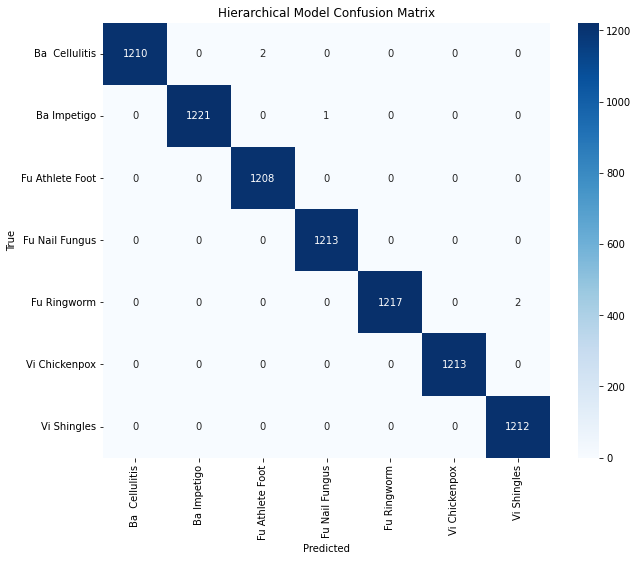

In [73]:
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Get ground truth labels from folder names
test_dir = "split_dataset/test"
true_labels = []
pred_labels = []

for class_folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_folder)
    if not os.path.isdir(class_path) or class_folder.startswith('.'):
        continue

    for img_file in os.listdir(class_path):
        if img_file.startswith('.'):
            continue
        img_path = os.path.join(class_path, img_file)

        # Stage 1 + Stage 2 prediction
        prediction = hierarchical_predict(img_path)  # {'Stage 1': '...', 'Stage 2': '...'}
        
        true_labels.append(class_folder)  # True subtype label from folder name
        pred_labels.append(prediction["Stage 2"])  # Predicted subtype

# Metrics
#print("Pipeline Accuracy:", accuracy_score(true_labels, pred_labels))
print("\nClassification Report:\n", classification_report(true_labels, pred_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=sorted(list(set(true_labels))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(list(set(true_labels))),
            yticklabels=sorted(list(set(true_labels))))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hierarchical Model Confusion Matrix")
plt.show()
